# Homework 3: Time Series and Extreme Values

BEE 4850/5850, Spring 2026

**Name**:

**ID**:

> **Due Date**
>
> Friday, 3/14/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to diagnose autocorrelation and develop an AR
    model for the weather-based variability at the Sewell’s Point tide
    gauge.
-   Problem 2 asks you to fit a sea-level rise model under both
    assumptions of Gaussian i.i.d. residuals and autocorrelated
    residuals.
-   Problem 3 asks you to conduct an analysis of extreme temperatures in
    Ithaca under both stationary and non-stationary assumptions.
-   Problem 4 asks you to model how often Ithaca temperatures exceed
    thresholds.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.Registry.update()
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()

  Activating project at `c:\Users\nicho\Documents\hw03-NickZajac56`
    Updating registry at `C:\Users\nicho\.julia\registries\General.toml`
     Project No packages added to or removed from `C:\Users\nicho\Documents\hw03-NickZajac56\Project.toml`
    Manifest No packages added to or removed from `C:\Users\nicho\Documents\hw03-NickZajac56\Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # some other dataframes interaction macros
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using Dates # date-time interface

## Problems

### Scoring

-   Problem 1 is worth 5 points.
-   Problem 2 is worth 8 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1 (4 points)

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

#### Problem 1.1

Load the data file. Take the difference between the observations and the
sinusoidal predictions to obtain the tide level which could be
attributed to weather-related variability (since for one year sea-level
rise and other factors are unlikely to matter). Plot this data. What
autoregressive model order would you pick?

#### Problem 1.2

Fit an AR(1) model for the weather-related variability in the Norfolk
tide gauge. Simulate 10,000 replications of this model, add the
simulations back to the sinusoidal harmonics, and plot a histogram of
the maximum and median tide levels from your simulations. How well does
this model do in capturing these statistics from the observed dataset?

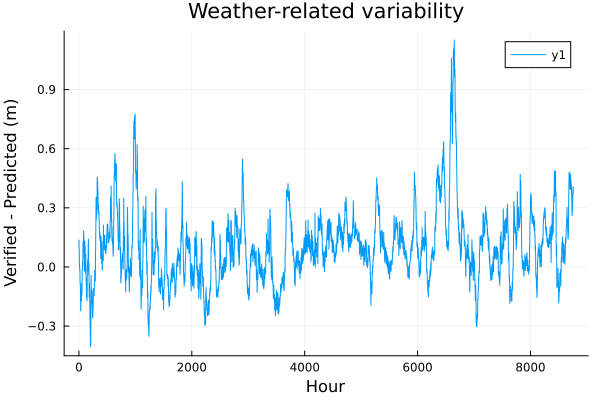

In [3]:
#Problem 1.1

#Load data file
tide = CSV.read("data/norfolk-hourly-surge-2015.csv", DataFrame)

#compute differnece
tide_diff = tide.var"Verified (m)" - tide.var"Predicted (m)"

#plot code
plot(tide_diff, xlabel = "Hour", ylabel = "Verified - Predicted (m)", 
    title = "Weather-related variability")


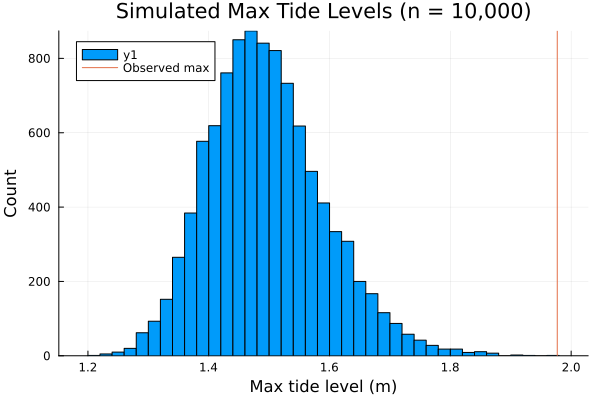

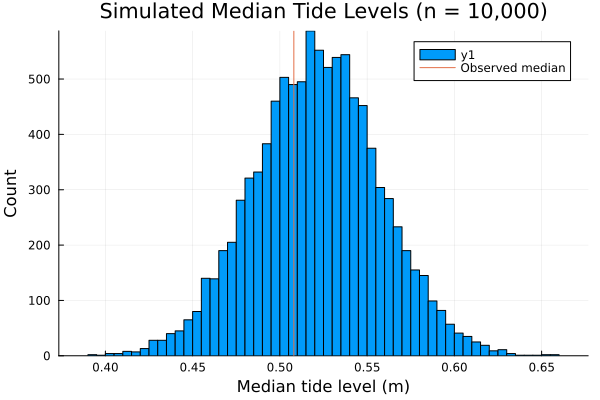

In [4]:
#Problem 1.2

#set parameters for AR(1) equation

x = tide_diff
y = x[2:end]
X = [ones(length(y)) x[1:end-1]]

beta = X \ y #estimates regression coefficients for alpha and rho
alpha = beta[1]
rho = beta[2]

#Set residual and epsilon 
resid = y - X*beta 
epsilon = std(resid) #assumed to come from random noise

pred = tide.var"Predicted (m)"
obs = tide.var"Verified (m)"
T = length(x)

n_sims = 10000
Random.seed!(44)

#Store max and min values

maxvals = zeros(n_sims)
medianvals = zeros(n_sims)

#for loop for sims 

for i in 1:n_sims
    sim = zeros(T)
    sim[1] = x[1]
    for t in 2:T #lag
        sim[t] = alpha + rho*sim[t-1] + epsilon*randn() #AR(1) equation
    end
    
    #store max and median values for each iteration
    total = pred .+ sim
    maxvals[i] = maximum(total)
    medianvals[i] = median(total)
end

#observed max and median
obs_max = maximum(obs)
obs_med = median(obs)

#plot code
p1 = histogram(maxvals, bins = 50, xlabel = "Max tide level (m)", ylabel = "Count",
   title = "Simulated Max Tide Levels (n = 10,000)")
   vline!([obs_max], label = "Observed max")

p2 = histogram(medianvals, bins = 50, xlabel = "Median tide level (m)", ylabel = "Count",
    title = "Simulated Median Tide Levels (n = 10,000)")
    vline!([obs_med], label = "Observed median")

display(p1)
display(p2)

Problem 1.1

I would use an AR(1) model.

Problem 1.2

Given the two graphs above, I would say that the model performs okay at capturing the statistics from the observed dataset.  The observed median tide level is pretty close to the center of the simulated median tide level distriubtion.  Conversely, the observed maximum tide level was significantly different in comparison to the simulated maximum tide level distribution.  The observed maximum tide level is located near the very upper end of the distriubtion, which tells me that the AR(1) model underestimated the extreme tide events.

### Problem 2

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

As discussed in class, we can use a simple numerical integration method
(forward Euler integration) to convert this differential equation into a
difference equation, modeling an updated sea level state
$S(t + \Delta t)$ as a function of $S(t)$ and the model parameters. We
will also need an additional uncertain parameter $S_0 = S(0)$ to
initialize the integrated model.

#### Problem 2.1

Load the data from the `data/` folder and, following Grinsted et al
(2010), normalize both datasets to a 1880-1900 mean (subtract that mean
from the data). \* Global mean temperature data from the HadCRUT 5.0.2.0
dataset
(<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
can be found in
`data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`. This
data is averaged over the Northern and Southern Hemispheres and over the
whole year. \* Global mean sea level anomalies (relative to the 1990
mean global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
courtesy of CSIRO
(<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The standard
deviation of the estimate is also added for each year.

Plot the resulting datasets.


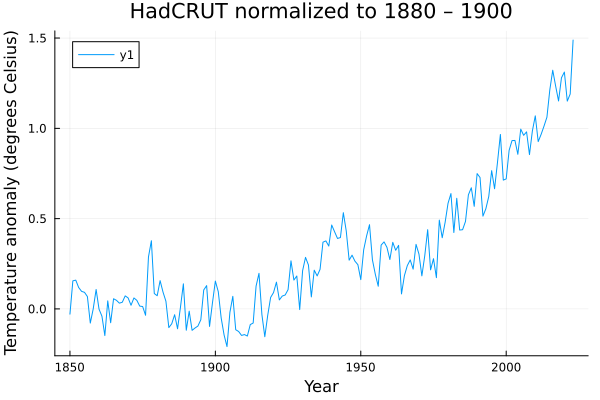

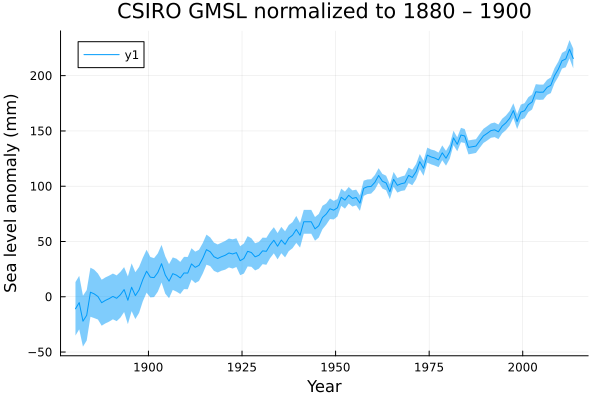

In [5]:
#load data

df_temp = CSV.read("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", DataFrame)
df_sealevel = CSV.read("data/CSIRO_Recons_gmsl_yr_2015.csv", DataFrame)

#store values for plots

temp_year = df_temp[:,1]
temp_anomaly = df_temp[:,2]

sealevel_year = df_sealevel[:,1]
sealevel_mm = df_sealevel[:,2]
sealevel_sd = df_sealevel[:,3]

#normalize

temp_1 = mean(temp_anomaly[(temp_year .>= 1880) .& (temp_year .<= 1900)])
sl_1 = mean(sealevel_mm[(sealevel_year .>= 1880) .& (sealevel_year .<= 1900)])

temp_norm = temp_anomaly .- temp_1
sl_norm = sealevel_mm .- sl_1

#plot code

p1 = plot(temp_year, temp_norm, xlabel = "Year", ylabel = "Temperature anomaly (degrees Celsius)",
    title = "HadCRUT normalized to 1880 – 1900")
display(p1)

#ribbon to add in standard deviation
p2 = plot(sealevel_year, sl_norm, ribbon = sealevel_sd, xlabel = "Year", ylabel = "Sea level anomaly (mm)",
    title = "CSIRO GMSL normalized to 1880 – 1900")
display(p2)

#### Problem 2.2

Write a function to simulate global mean sea levels under a set of model
parameters after discretizing the equations above with a timestep of
$\delta t = 1$ yr. You will need to subset the temperature data to the
years where you also have sea-level data.

Fit the model under the assumption of Gaussian i.i.d. residuals (include
both an uncertain model error term and the standard deviation of the
observations in the probability model specification) by maximizing the
likelihood. Report the parameter estimates. What can you conclude about
the relationship between global mean temperature increases and global
mean sea level rise rates? How appropriate was the Gaussian i.i.d.
probability model for the residuals? Use any needed quantitative or
qualitative assessments of goodness of fit to justify your answer. If
this was not an appropriate probability model, what would you change?

In [15]:
#subset to years that have sea level data

temp_year_int = Int.(temp_year)

#Forces CSIRO time to go from 1880.5 to 1880 to be used
sealevel_year_int = floor.(Int, sealevel_year)

#join the 2 loaded csvs together
temp_ss = DataFrame(year = temp_year_int, T = temp_norm)
sl_ss   = DataFrame(year = sealevel_year_int, S = sl_norm, sd = sealevel_sd)
data_joined = innerjoin(sl_ss, temp_ss, on=:year)

years = data_joined.year
T = data_joined.T
Sobs = data_joined.S
Ssd  = data_joined.sd

#euler simulation with 1 year timestep
#make function to call later

function simulate_sealevel(T, a, b, tau, S0)
    n = length(T)
    S = zeros(n)
    S[1] = S0
    for t in 1:(n-1)
        Seq = a*T[t] + b #from given equation
        S[t+1] = S[t] + (Seq - S[t]) / tau
    end
    return S
end

#now get log likelihood

function ll_iid(theta)

    #set variables to be able to call above function
    a = theta[1]
    b = theta[2]
    tau = exp(theta[3])
    S0 = theta[4]
    std_m = exp(theta[5]) #extra uncertain model error term

    #call function and get residuals and total standard deviation
    Smod = simulate_sealevel(T, a, b, tau, S0)
    r = Sobs .- Smod 
    s = sqrt.(std_m^2 .+ Ssd.^2)
    
    return sum(logpdf.(Normal.(0.0, s), r))
end



#Optimize similar to fish example in lecture
#log transforming variables that must be positive

lb = [0.0, -2000.0, log(1.0), minimum(Sobs) - 1000.0, log(0.0001)]
ub = [5000.0, 2000.0, log(500.0), maximum(Sobs) + 1000.0, log(500.0)]

init = [100.0, 0.0, log(50.0), Sobs[1], log(10.0)]

optim_out = optimize(theta -> -ll_iid(theta), lb, ub, init)
theta_mle = Optim.minimizer(optim_out)

a_hat     = theta_mle[1]
b_hat     = theta_mle[2]
tau_hat   = exp(theta_mle[3])
s0_hat    = theta_mle[4]
sigma_hat = exp(theta_mle[5])

println(a_hat)
println(b_hat)
println(tau_hat)
println(s0_hat)
println(sigma_hat)

506.10796010829733
180.29444204384657
149.95272113178797
-9.046304591168118
0.00010006688126685653


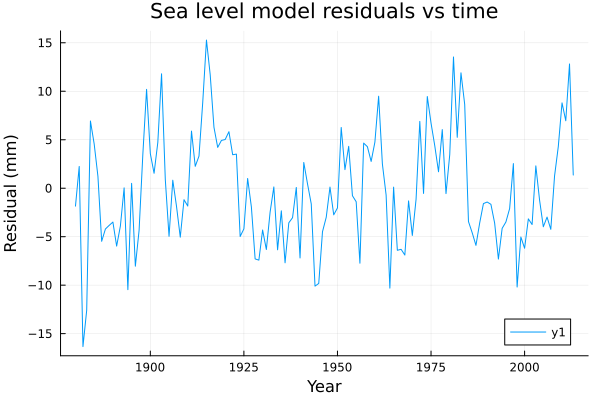

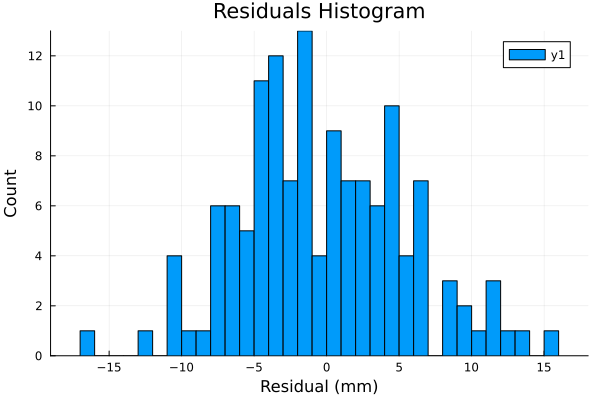

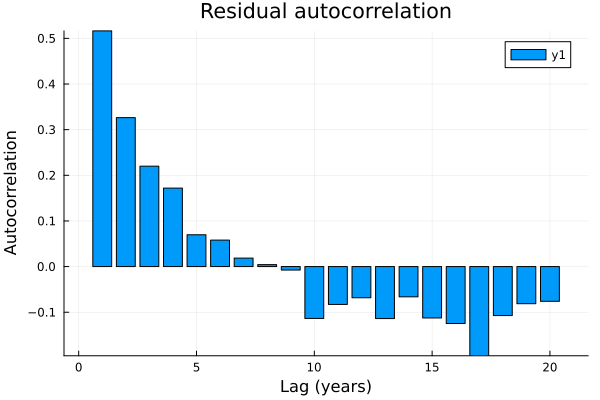

In [7]:
#Check Gaussian iid

#Rerun model using MLE parameters
Smodel_hat = simulate_sealevel(T, a_hat, b_hat, tau_hat, s0_hat)
r = Sobs .- Smodel_hat

#Plot code using calculated residuals
p1 = plot(years, r, xlabel = "Year", ylabel = "Residual (mm)", title = "Sea level model residuals vs time")
display(p1)

#Histogram of residuals
p2 = histogram(r, bins = 50, xlabel = "Residual (mm)", ylabel = "Count", title = "Residuals Histogram")
display(p2)

#Bar graph to check autocorrelation
#check autocorrelation lag (1:20)
acf = autocor(r, 1:20)
p3 = plot(1:20, acf, seriestype = :bar, xlabel = "Lag (years)", 
    ylabel = "Autocorrelation", title = "Residual autocorrelation")
display(p3)

The parameter estimates are as follows:

a: 506.11
b: 180.29
Tau: 149.95
S0: -9.05
sigma: 0.0001 (going to lower bound)

From our results we can see that parameter a is positive which indicates that a higher global mean temperature is related to a higher global mean sea level.  From the provided equation, and substituting aT + b into Seq, we can see that increases in temperature also are related to sea level rise rates.

The first two residual plots actually point towards somewhat Gaussian with a pretty random residuals vs time plot and the histogram of residuals appearing pretty normally distriubted as well.  However, the autocorrelation graph provides strong evidence that there is strong autocorrelation and dependence within the model.  Therefore, the Gaussian iid probability was not appropriate as the iid is violated

As this is not an appropriate probability model I would change it to be an autoregressive model.



#### Problem 2.3

Now redo Problem 2.2 but with an AR(1) model for the residuals. You can
assume that the residual AR(1) model has mean zero (so $\alpha = 0$).
Did your model parameter estimates change? If so, what changed about
your conclusion(s) about the relationship between global mean
temperature increases and global mean sea level rise?

In [18]:

#AR(1) function to call
function ar1(rho, sigma, dat)
    Tn = length(dat)
    ll = 0.0
    for i in 1:Tn
        if i == 1
            ll += logpdf(Normal(0.0, sqrt(sigma^2 / (1 - rho^2))), dat[i])
            #^assume alpha = 0
        else
            r = dat[i] - rho * dat[i-1]
            ll += logpdf(Normal(0.0, sigma), r)
        end
    end
    return ll
end

function ll_ar1_residuals(theta)
    #structural params
    a = theta[1]
    b = theta[2]
    tau = exp(theta[3])
    S0  = theta[4]

    # AR(1) params (transforms enforce constraints)
    rho = (theta[5])    
    sigma = exp(theta[6])       #sd for residuals

    #model + residuals
    Smod = simulate_sealevel(T, a, b, tau, S0)
    r    = Sobs .- Smod

    return ar1(rho, sigma, r)
end

#now optimize

lb = [0.0, -2000.0, log(1.0),  minimum(Sobs) - 1000.0, -.95, log(0.001)]
ub = [5000.0, 2000.0, log(500.0), maximum(Sobs) + 1000.0, .95, log(50.0)]

init = [a_hat, b_hat, log(tau_hat), s0_hat,0.5, log(std(r))]

optim_out_ar = optimize(theta -> -ll_ar1_residuals(theta), lb, ub, init)
theta_m = Optim.minimizer(optim_out_ar)

a_hat_ar = theta_m[1]
b_hat_ar = theta_m[2]
tau_hat_ar = exp(theta_m[3])
s0_hat_ar = theta_m[4]
rho_hat_ar = theta_m[5]
sigma_eta_hat = exp(theta_m[6])


println(a_hat_ar)
println(b_hat_ar)
println(tau_hat_ar)
println(s0_hat_ar)
println(rho_hat_ar)
println(sigma_eta_hat)

534.5450347949951
199.63642788872235
166.0406666563997
-10.01348219379649
0.5110277763388926
4.935112171203329


The parameter estimates are as follows:
a: 534.58
b: 199.64
Tau: 166.04
S0: -10.01
rho = 0.51
sigma(ar(1)) = 4.94

so compared to the previous model parameter estimates:
a: 506.11
b: 180.29
Tau: 149.95
S0: -9.05
sigma: 0.0001 (going to lower bound)

They have changed.  Sigma is now not approaching the lower bound, and the other parameters show changes as well.  All of a, b, and tau now are slightly increased in value after the AR(1) model.  The rho value being 0.51 indicates a notable autocorrelation presence.  

Even though the parameter estimates have changed, the main takeaways from the relationship between global mean temperature increases and global mean sea level rise have not changed.  a is still positive and indicates that higher global mean temperature is related to high global mean sea level

### Problem 3

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

#### Problem 3.1

Load the (daily maximum) temperature data from
`data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
temperatures and plot them.

#### Problem 3.2

Fit a stationary GEV model to the annual maximum series and report your
parameter estimates. Plot the fitted distribution along with the data.
What type of GEV distribution did you end up with? What is the 100-year
return level?

#### Problem 3.3

Now fit a nonstationary GEV with respect to time (only the location
parameter should be non-stationary),
$y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling purposes,
begin with $t=0$ corresponding to 1850). Plot how the 100 year return
levels change over time. Do you get the same return level today as in
Problem 3.2?

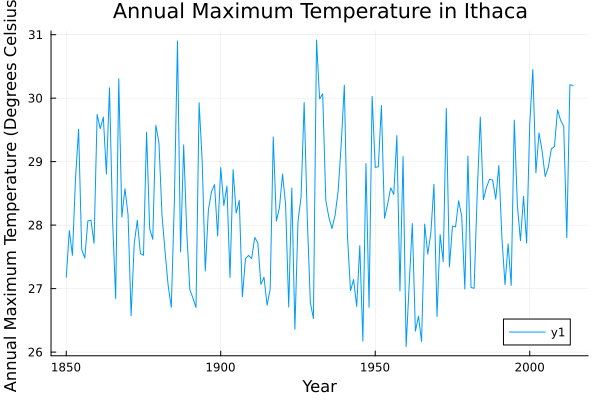

In [9]:
df_temp = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)

#Split date in dataframe up by day and year

df_temp.Day = Date.(df_temp.Day)               
df_temp.year = year.(df_temp.Day)

#Split years up and find annual max temp

years = year.(df_temp.Day)
unique_years = unique(years)

annual_max = zeros(length(unique_years))

for i in eachindex(unique_years)
    year = unique_years[i]
    annual_max[i] = maximum(df_temp.TempMax[years .== year])
end

#plot code

plot(unique_years, annual_max, xlabel = "Year", ylabel = "Annual Maximum Temperature (Degrees Celsius)", 
title = "Annual Maximum Temperature in Ithaca")


27.828895474353924
1.0168352688408009
-0.21878753177524754
30.77773559418467


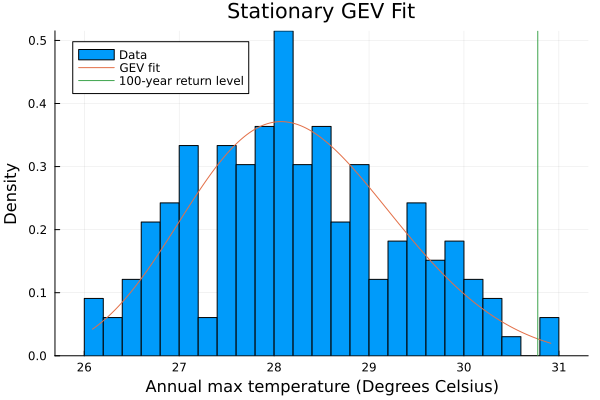

In [ ]:
y = annual_max

#function to fit GEV model
function ll_gev_stationary(params)

    mu = params[1]
    sigma = exp(params[2])
    xi = params[3]

   val = GeneralizedExtremeValue(mu, sigma, xi)
   
   return sum(logpdf.(val, y))
end

#establish bounds and initial
lb_3 = [minimum(y) - 10.0, log(0.01), -0.5]
ub_3 = [maximum(y) + 10.0, log(50.0), 0.5]
init_3 = [mean(y), log(std(y)), 0.1]

#optimize the staionary function

opt_3 = optimize(p -> -ll_gev_stationary(p), lb_3, ub_3, init_3)

p_hat = Optim.minimizer(opt_3)

mu_hat = p_hat[1]
sigma_hat_3 = exp(p_hat[2])
xi_hat = p_hat[3]

#call function and get 100 year return level

val_hat = GeneralizedExtremeValue(mu_hat, sigma_hat_3, xi_hat)

level_100 = quantile(val_hat, 0.99)



println(mu_hat)
println(sigma_hat_3)
println(xi_hat)
println(level_100)

#plot code

histogram(y, bins = 30, normalize = true, xlabel = "Annual max temperature (Degrees Celsius)", 
ylabel = "Density", title = "Stationary GEV Fit", label = "Data")

xgrid = range(minimum(y), maximum(y), length = 200)

plot!(xgrid, pdf.(val_hat, xgrid), label="GEV fit")

vline!([level_100], label="100-year return level")

30.77773559418467
30.93092269274198


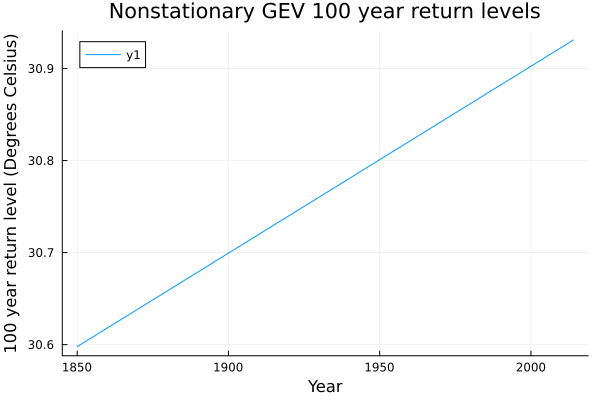

In [19]:
t = unique_years .- 1850

#funciton for nonstationary GEV

function ll_gev_nonstationary(params)

    mu0 = params[1]
    mu1 = params[2]
    sigma = exp(params[3])
    xi = params[4]

    mu_t = mu0 .+ mu1 .* t

    ll = 0.0

    for i in eachindex(y)
        val_2 = GeneralizedExtremeValue(mu_t[i], sigma, xi)
        ll += logpdf(val_2, y[i])
    end

    return ll 

end


#establish bounds and initial

lb_2 = [minimum(y) - 10.0, -5, log(0.01), -0.5]
ub_2 = [maximum(y) + 10.0, 5, log(50.0), 0.5]

init_2 = [mu_hat, 0.0, log(sigma_hat_3), xi_hat]

#optimize using nonstationary function
opt_out_2 = optimize(p -> -ll_gev_nonstationary(p), lb_2, ub_2, init_2)
p_hat_2 = Optim.minimizer(opt_out_2)

mu0_hat_2 = p_hat_2[1]
mu1_hat_2 = p_hat_2[2]
sigma_hat_2 = exp(p_hat_2[3])
xi_hat_2 = p_hat_2[4]

mu_t_hat = mu0_hat_2 .+ mu1_hat_2 .* t 

#get 100 year return level
level_100_2 = zeros(length(mu_t_hat))

for i in eachindex(mu_t_hat)

    val_2 = GeneralizedExtremeValue(mu_t_hat[i], sigma_hat_2, xi_hat_2)
    level_100_2[i] = quantile(val_2, 0.99)
end

println(level_100)
println(level_100_2[end])

#plot code

plot(unique_years, level_100_2, xlabel = "Year", ylabel = "100 year return level (Degrees Celsius)", 
    title = "Nonstationary GEV 100 year return levels")



Problem 3.2

I ended up with a Weibull type of GEV distriubtion since my Xi value was <0.  The 100 year return level is 30.78 degrees Celsius.


Problem 3.3

While I did not get the exact same return level today as in problem 3.2, it was a similar result.  As stated above, for 3.2 I got 30.78 Degrees Celsius, but for 3.3, using a nonstationary GEV, I got 30.93 degrees Celsius.  This, to me, seems like a logical result.  By allowing the distribution to have a temporal component to it, or allowing it to change over time, this model can better reflect climate trends.  This better models global warming and leads to a slightly elevated 100 year return level than the stationary model.



### Problem 4

Now let’s analyze how often the Ithaca temperature data exceeds certain
thresholds.

#### Problem 4.1

Suppose that we were interested in looking at temperature exceedances
over 28°C. Decluster these occurrences and plot the number of
exceedances by year. Have they increased over time?

#### Problem 4.2

Fit a stationary Poisson-GPD model for the exceedances. What does the
GPD distribution look like?

#### Problem 4.3

From your model, estimate the 100-year return level. How does it differ
from the 100-year return period from the stationary model in Problem 3?
Why do you think it agrees or disagrees?

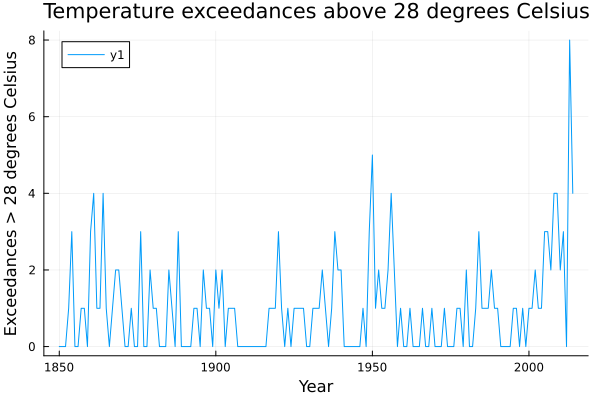

In [20]:
#Set variables
threshold = 28

temps = df_temp.TempMax
years_4 = year.(df_temp.Day)

event_years = Int[]


#for loop to determine number of events per year (decluster)
for i in 2:length(temps)
    if temps[i] > threshold && temps[i-1] <= threshold
        push!(event_years, years_4[i])
    end
end

unique_years_exceed = sort(unique(years_4))

#get exeedance count for each year
counts = [sum(event_years .== y) for y in unique_years_exceed]

#plot code

plot(unique_years_exceed, counts, xlabel = "Year", 
    ylabel = "Exceedances > 28 degrees Celsius", 
    title = "Temperature exceedances above 28 degrees Celsius")

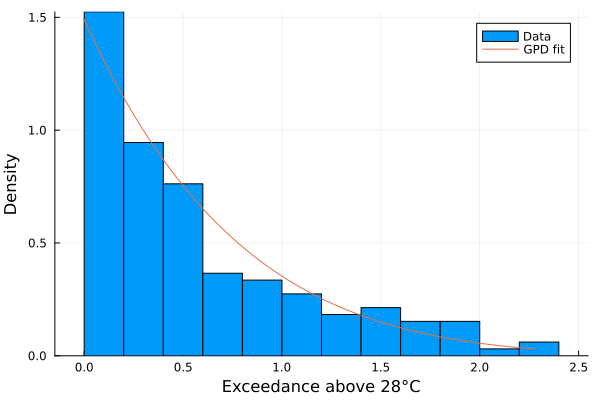

In [13]:
#get excess for GPD distribution

excess = Float64[]

for i in 2:length(temps)
    if temps[i] > threshold && temps[i-1] <= threshold
        push!(excess, temps[i] - threshold)
    end
end

#Set up function for GPD
function ll_gpd(params4)
    
    sigma4 = exp(params4[1])
    xi4 = params4[2]

    val4 = GeneralizedPareto(sigma4, xi4)
    
    return sum(logpdf.(val4, excess))
end

#set bounds and optimize
lb4 = [log(0.01), -1]
ub4 = [log(50.0), 1]

init4 = [log(std(excess)), 0.1]

opt4 = optimize(p -> -ll_gpd(p), lb4, ub4, init4)

p_hat4 = Optim.minimizer(opt4)

sigma_hat4 = exp(p_hat4[1])
xi_hat4 = p_hat4[2]

fit = GeneralizedPareto(sigma_hat4, xi_hat4)

#plot code

xgrid = range(0, maximum(excess), length = 200)

histogram(excess, bins = 20, normalize=true, xlabel = "Exceedance above 28°C",
    ylabel = "Density", label = "Data")

plot!(xgrid, pdf.(fit, xgrid), label = "GPD fit")

In [ ]:
lambda = length(event_years) / length(unique_years_exceed)

#get 100 year return level from the gpd
p = 1 -(1 / (100 * lambda))

return_level_4 = threshold + quantile(fit, p)

print(return_level_4)

30.31580864004223

Problem  4.1

It's hard to say, if it wasn't for the high spike about 10 years ago the data would not really indicate an increase in exceedances over time.  There is a pretty healthy spread that goes back and forth between ~0 and 6 from 1850 until ~2010 so I would be reluctant to say that exceedances have increased in this time frame.


Problem 4.2

The GPD distriubtion resembles a right-hand skew histogram, in the sense that there is a higher density on the left-hand side of the X axis and it tails off towards the right-hand side of the X axis.  This histogram shows that there is a higher concentration of smaller exceedances and that larger exceedances become generally rarer.

Problem 4.3

The 100 year return level, as calculated from this model, was 30.32 degrees Celsius.  This does not differ much from the stationary model in Problem 3, as that was calculated to be 30.77 degrees Celsius.

I think they agree because they both are both ways to model extreme value theory where GEV uses block maxima and GPD uses peaks over threshold.  So, they are both using the same data to model extreme values and there are only minor differences in the actual outputs.


## References

OpenAI. (2024). ChatGPT (Sept 25 GPT-5 version) [Large language model].
https://chat.openai.com:  I utilized ChatGPT to help specifically with code development and some julia-specific syntax guidance.  The main ideas behind the code formulation and the actual analysis was performed by me.